In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [2]:
# Coordinates of cities
np.random.seed(42)
cities = np.random.rand(10, 2) * 10

# Compute distance matrix
def distance_matrix(cities):
    n = len(cities)
    dist = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            dist[i][j] = np.linalg.norm(cities[i] - cities[j])
    return dist

dist_matrix = distance_matrix(cities)

In [3]:
num_ants = 20
num_iterations = 100
alpha = 1      # pheromone importance
beta = 2       # distance importance
evaporation = 0.8
Q = 50

num_cities = len(cities)
pheromone = np.ones((num_cities, num_cities)) * 0.01

In [4]:
def route_length(route):
    length = 0
    for i in range(len(route)):
        length += dist_matrix[route[i]][route[(i+1) % len(route)]]
    return length

In [5]:
best_route = None
best_length = float('inf')
history = []

for iteration in range(num_iterations):
    all_routes = []
    avg_history = []

    for ant in range(num_ants):
        route = [random.choice(range(num_cities))]
        
        while len(route) < num_cities:
            current = route[-1]
            probabilities = []
            
            for j in range(num_cities):
                if j not in route:
                    tau = pheromone[current][j] ** alpha
                    eta = (1 / dist_matrix[current][j]) ** beta + 1e-6
                    probabilities.append(tau * eta)
                else:
                    probabilities.append(0)

            probabilities = np.array(probabilities)

            # 👉 ADD FIX HERE
            if probabilities.sum() == 0:
                probabilities = np.ones(num_cities) / num_cities
            else:
                probabilities /= probabilities.sum()

            exploration_rate = 0.4   # 40% random exploration

            if random.random() < exploration_rate:
                next_city = random.choice([j for j in range(num_cities) if j not in route])
            else:
                next_city = np.random.choice(range(num_cities), p=probabilities)
            route.append(next_city)
        
        all_routes.append(route)
        
        length = route_length(route)
        if length < best_length:
            best_length = length
            best_route = route
    
    # Pheromone evaporation
    pheromone *= (1 - evaporation)
    pheromone = np.clip(pheromone, 0.01, 5)
    
    # Pheromone update
    for route in all_routes:
        length = route_length(route)
        # 🔥 Elite update (VERY IMPORTANT)
        for i in range(len(best_route)):
            a = best_route[i]
            b = best_route[(i+1) % len(best_route)]
            
            pheromone[a][b] += Q / best_length
            pheromone[b][a] += Q / best_length  # symmetric update
    
    avg_length = np.mean([route_length(r) for r in all_routes])
    avg_history.append(avg_length)

    history.append(best_length)
    
    print(f"Iteration {iteration+1}, Best Distance: {best_length:.4f}")

Iteration 1, Best Distance: 29.0318
Iteration 2, Best Distance: 29.0318
Iteration 3, Best Distance: 29.0318
Iteration 4, Best Distance: 29.0318
Iteration 5, Best Distance: 29.0318
Iteration 6, Best Distance: 29.0318
Iteration 7, Best Distance: 29.0318
Iteration 8, Best Distance: 29.0318
Iteration 9, Best Distance: 29.0318
Iteration 10, Best Distance: 29.0318
Iteration 11, Best Distance: 29.0318
Iteration 12, Best Distance: 29.0307
Iteration 13, Best Distance: 29.0307
Iteration 14, Best Distance: 29.0307
Iteration 15, Best Distance: 29.0307
Iteration 16, Best Distance: 29.0307
Iteration 17, Best Distance: 29.0307
Iteration 18, Best Distance: 29.0307
Iteration 19, Best Distance: 29.0307
Iteration 20, Best Distance: 29.0307
Iteration 21, Best Distance: 29.0307
Iteration 22, Best Distance: 29.0307
Iteration 23, Best Distance: 29.0307
Iteration 24, Best Distance: 29.0307
Iteration 25, Best Distance: 29.0307
Iteration 26, Best Distance: 29.0307
Iteration 27, Best Distance: 29.0307
Iteration 

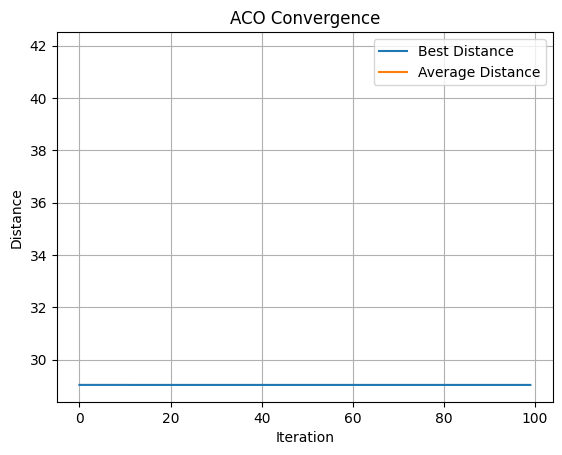

In [6]:
plt.plot(history, label="Best Distance")
plt.plot(avg_history, label="Average Distance")
plt.legend()
plt.title("ACO Convergence")
plt.xlabel("Iteration")
plt.ylabel("Distance")
plt.grid()
plt.show()

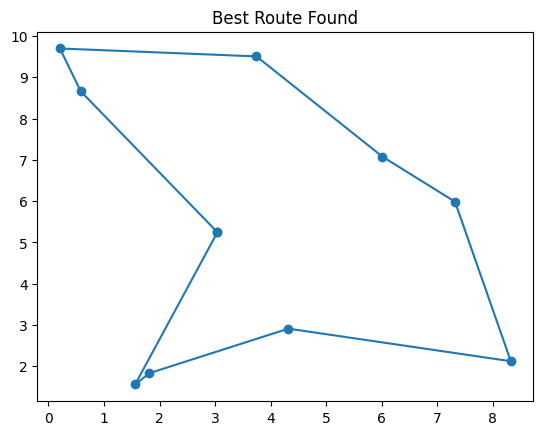

In [7]:
best_route_cycle = best_route + [best_route[0]]
coords = cities[best_route_cycle]

plt.plot(coords[:,0], coords[:,1], marker='o')
plt.title("Best Route Found")
plt.show()